<a href="https://colab.research.google.com/github/ANATOLYTIMO/backend_test_homework/blob/master/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Untitled14_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = sns.load_dataset('tips')

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
print(df.isnull().sum())

duplicates_count = df.duplicated().sum()

if duplicates_count > 0:
    df = df.drop_duplicates()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [ ]:
print(df.describe())
print(df.describe(include=['category']))

       total_bill         tip        size
count  243.000000  243.000000  243.000000
mean    19.813868    3.002387    2.572016
std      8.910071    1.385002    0.952356
min      3.070000    1.000000    1.000000
25%     13.380000    2.000000    2.000000
50%     17.810000    2.920000    2.000000
75%     24.175000    3.575000    3.000000
max     50.810000   10.000000    6.000000
         sex smoker  day    time
count    243    243  243     243
unique     2      2    4       2
top     Male     No  Sat  Dinner
freq     157    151   87     176


16.08%


<Axes: title={'center': 'Распределение процента чаевых'}, ylabel='Frequency'>

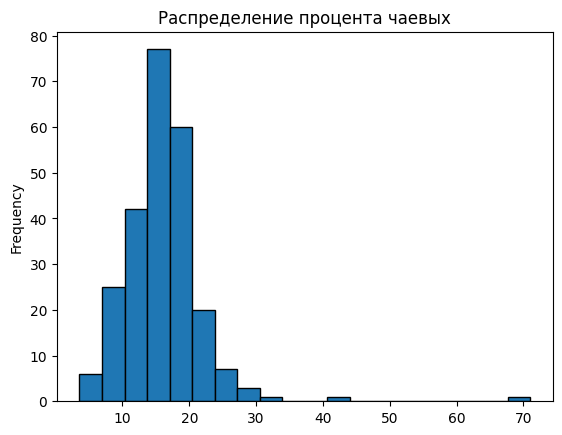

In [ ]:
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100
print(f"{df['tip_percentage'].mean():.2f}%")
df['tip_percentage'].plot(kind='hist', bins=20, title='Распределение процента чаевых', edgecolor = "black")

In [ ]:
pivot_table = df.pivot_table(values='tip_percentage',
                             index='day',
                             columns='sex',
                             aggfunc='mean')
pivot_table

/tmp/ipykernel_6627/2300206545.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(values='tip_percentage',


sex,Male,Female
day,,
Thur,16.527649,15.764350
Fri,14.338519,19.938840
Sat,15.157684,15.647021
Sun,16.234407,18.156877


In [ ]:
df.groupby(["time", "smoker"])["total_bill"].mean()

/tmp/ipykernel_6627/766447151.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["time", "smoker"])["total_bill"].mean()


time    smoker
Lunch   Yes       17.599091
        No        17.050889
Dinner  Yes       21.859429
        No        20.095660
Name: total_bill, dtype: float64

<Axes: title={'center': 'Зависсимость чаевы от суммы счета'}, xlabel='total_bill', ylabel='tip'>

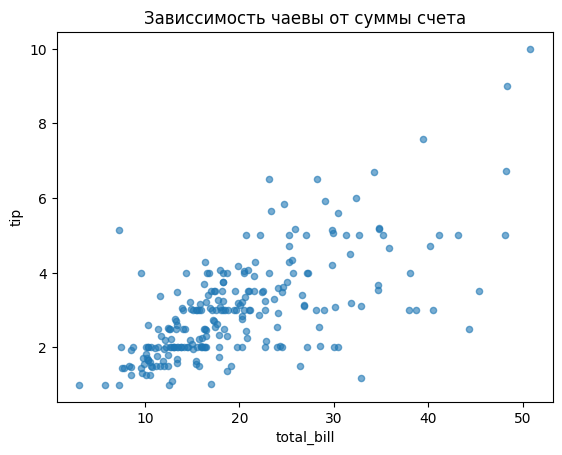

In [ ]:
df.plot(
    kind="scatter",
    x="total_bill",
    y="tip",
    title="Зависсимость чаевы от суммы счета",
    alpha=0.6
)

<Axes: title={'center': 'total_bill'}, xlabel='day'>

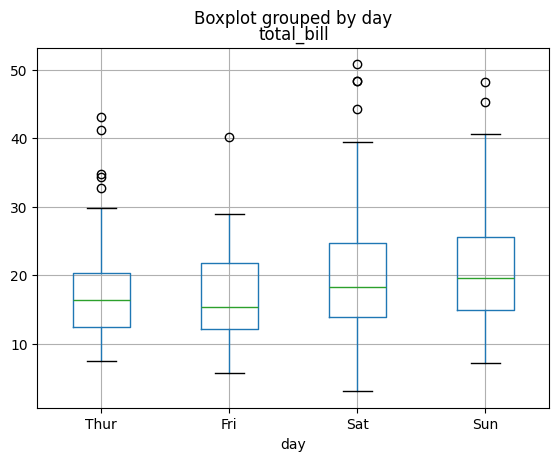

In [ ]:
df.boxplot(column="total_bill", by="day")

In [ ]:
size_impact = df.groupby("size")["tip_percentage"].mean()

<Axes: title={'center': 'Средний размер чаевых в зависимости от размера компании'}, xlabel='size', ylabel='Процент чаевых'>

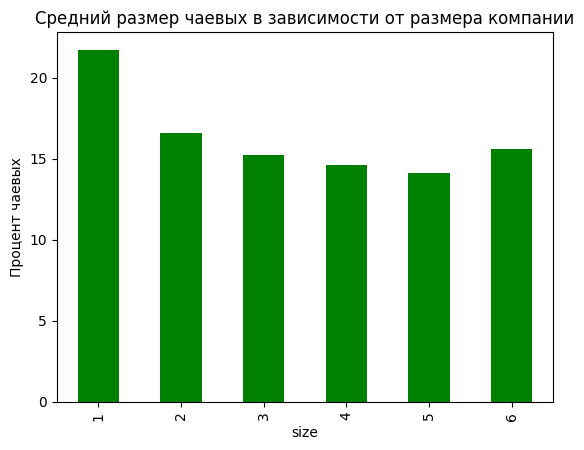

In [ ]:
size_impact.plot(
    kind="bar",
    title="Средний размер чаевых в зависимости от размера компании",
    color="green",
    ylabel="Процент чаевых"
)

Text(0.5, 0, 'Сумма чека')

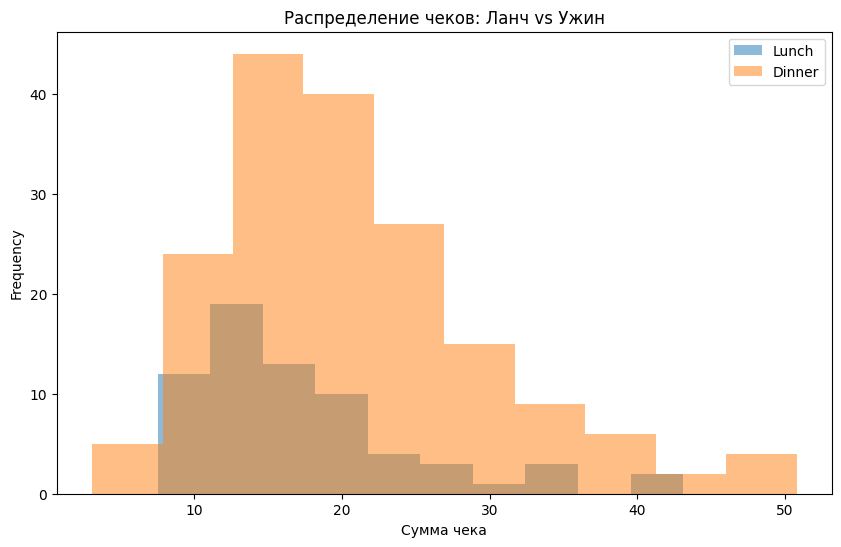

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
df[df['time'] == 'Lunch']['total_bill'].plot(kind='hist', alpha=0.5, label='Lunch', ax=ax)
df[df['time'] == 'Dinner']['total_bill'].plot(kind='hist', alpha=0.5, label='Dinner', ax=ax)

plt.legend()
plt.title('Распределение чеков: Ланч vs Ужин')
plt.xlabel('Сумма чека')